# Evaluation — honest test-set verdict (Ahmed)
Preprocessing + splits reused verbatim from 04_Modeling; models loaded from models/.

In [1]:
import os, hashlib, random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, f1_score, recall_score, precision_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASSES = ["Low Potential Dysgraphia", "Potential Dysgraphia"]
# Potential Dysgraphia is the class we care about recall for -> encode it as the
# positive class (1) so Keras's built-in Precision/Recall track it directly.
LABEL_MAP = {"Low Potential Dysgraphia": 0, "Potential Dysgraphia": 1}
POSITIVE_CLASS = "Potential Dysgraphia"

DATASET_ROOT = Path("data")
assert DATASET_ROOT.exists(), (
    f"Could not find '{DATASET_ROOT}'. Update DATASET_ROOT to point at the "
    f"unzipped dataset folder (the one that directly contains the class subfolders)."
)

TARGET_SIZE = (256, 256)  # width, height fed into preprocess_image

In [2]:
# --- reused from 02_data_quality_and_Image_Cleaning.ipynb (Step 2), unchanged ---

def standardize_colour(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def crop_borders(img, margin=10):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    x0, y0 = max(x - margin, 0), max(y - margin, 0)
    x1, y1 = min(x + w + margin, img.shape[1]), min(y + h + margin, img.shape[0])
    return img[y0:y1, x0:x1]

def deskew(img):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    if abs(angle) < 0.5:
        return img
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=0)

def resize_and_pad(img, target_size=TARGET_SIZE):
    h, w = img.shape
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas

def normalize(img):
    return img.astype("float32") / 255.0

def preprocess_image(path, target_size=TARGET_SIZE):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    img = standardize_colour(img)
    img = crop_borders(img)
    img = deskew(img)
    img = resize_and_pad(img, target_size)
    img = normalize(img)
    return img

# training-only augmentation, same as Step 2 — inactive at inference (training=False)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

In [3]:
# build a file index (mirrors notebook 01/02's tabular index)
records = []
for cls in CLASSES:
    folder = DATASET_ROOT / cls
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": str(folder / fname), "class": cls, "label": LABEL_MAP[cls]})

index_df = pd.DataFrame(records)
print("Total images:", len(index_df))
print(index_df["class"].value_counts())

Total images: 249
class
Low Potential Dysgraphia    135
Potential Dysgraphia        114
Name: count, dtype: int64


In [4]:
def load_images(df):
    X = np.stack([preprocess_image(p) for p in df["path"]])
    X = X[..., np.newaxis]  # (N, H, W, 1) — single grayscale channel
    y = df["label"].to_numpy(dtype="float32")
    return X, y

X_all, y_all = load_images(index_df)
print("X_all:", X_all.shape, "y_all:", y_all.shape)

X_all: (249, 256, 256, 1) y_all: (249,)


In [5]:
# 60 / 20 / 20 stratified split, test set held out untouched until final evaluation
train_idx, temp_idx = train_test_split(
    index_df.index, test_size=0.4, stratify=index_df["label"], random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=index_df.loc[temp_idx, "label"], random_state=SEED
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: n={len(y)}, Potential Dysgraphia={int(y.sum())} ({y.mean():.1%})")

train: n=149, Potential Dysgraphia=68 (45.6%)
val: n=50, Potential Dysgraphia=23 (46.0%)
test: n=50, Potential Dysgraphia=23 (46.0%)


In [8]:
import builtins
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, recall_score, precision_score, f1_score)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as _mobilenet_pi

y_test = np.asarray(y_test)
if y_test.ndim == 2 and y_test.shape[-1] == 2: y_test = y_test.argmax(-1)
else: y_test = y_test.reshape(-1).astype(int)

# make BOTH custom functions visible everywhere Keras looks for them
builtins.preprocess_image = preprocess_image
builtins.preprocess_input = _mobilenet_pi
co = {"preprocess_image": preprocess_image, "preprocess_input": _mobilenet_pi}

transfer = tf.keras.models.load_model("models/dysgraphia_transfer_model.keras",
                                      compile=False, safe_mode=False, custom_objects=co)
baseline = tf.keras.models.load_model("models/dysgraphia_baseline_model.keras",
                                      compile=False, safe_mode=False, custom_objects=co)
print("models loaded")


models loaded


--- Transfer (MobileNetV2) — TEST set ---
                          precision    recall  f1-score   support

Low Potential Dysgraphia       0.54      0.52      0.53        27
    Potential Dysgraphia       0.46      0.48      0.47        23

                accuracy                           0.50        50
               macro avg       0.50      0.50      0.50        50
            weighted avg       0.50      0.50      0.50        50

ROC AUC: 0.403


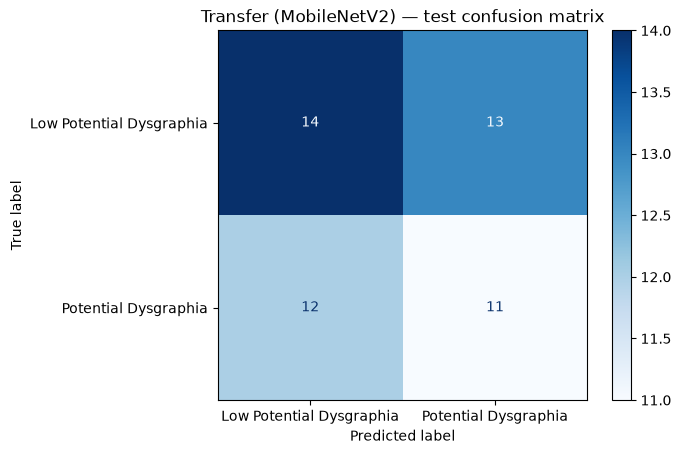

--- Baseline CNN — TEST set ---
                          precision    recall  f1-score   support

Low Potential Dysgraphia       0.54      1.00      0.70        27
    Potential Dysgraphia       0.00      0.00      0.00        23

                accuracy                           0.54        50
               macro avg       0.27      0.50      0.35        50
            weighted avg       0.29      0.54      0.38        50

ROC AUC: 0.765


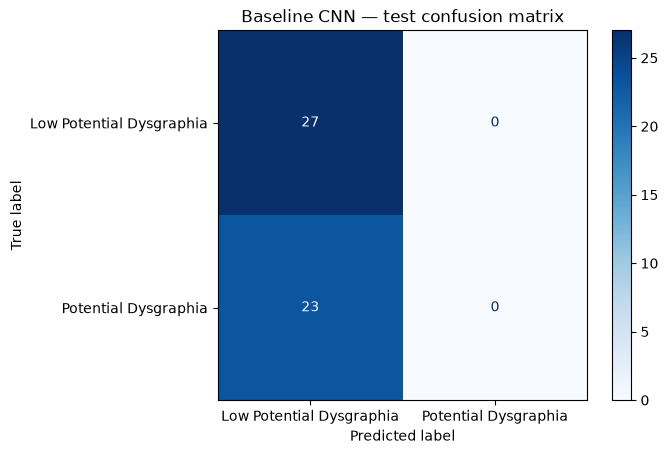

In [9]:
def evaluate_model(model, X, y, name):
    probs = model.predict(X, verbose=0).ravel()
    pred = (probs >= 0.5).astype(int)
    print(f"--- {name} — TEST set ---")
    print(classification_report(y, pred, target_names=CLASSES, zero_division=0))
    print("ROC AUC:", round(roc_auc_score(y, probs), 3))
    ConfusionMatrixDisplay(confusion_matrix(y, pred), display_labels=CLASSES).plot(cmap="Blues")
    plt.title(f"{name} — test confusion matrix")
    plt.show()
    return probs

probs_transfer = evaluate_model(transfer, X_test, y_test, "Transfer (MobileNetV2)")
probs_baseline = evaluate_model(baseline, X_test, y_test, "Baseline CNN")

In [10]:
print("threshold | recall | precision | f1")
for t in np.arange(0.30, 0.76, 0.05):
    p = (probs_transfer >= t).astype(int)
    print(f"   {t:.2f}   | {recall_score(y_test,p):.2f} | {precision_score(y_test,p):.2f} | {f1_score(y_test,p):.2f}")

threshold | recall | precision | f1
   0.30   | 1.00 | 0.46 | 0.63
   0.35   | 0.96 | 0.45 | 0.61
   0.40   | 0.91 | 0.44 | 0.59
   0.45   | 0.70 | 0.39 | 0.50
   0.50   | 0.48 | 0.46 | 0.47
   0.55   | 0.13 | 0.38 | 0.19
   0.60   | 0.00 | 0.00 | 0.00
   0.65   | 0.00 | 0.00 | 0.00
   0.70   | 0.00 | 0.00 | 0.00
   0.75   | 0.00 | 0.00 | 0.00


c:\Users\user\anaconda3\envs\group\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\group\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\group\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda

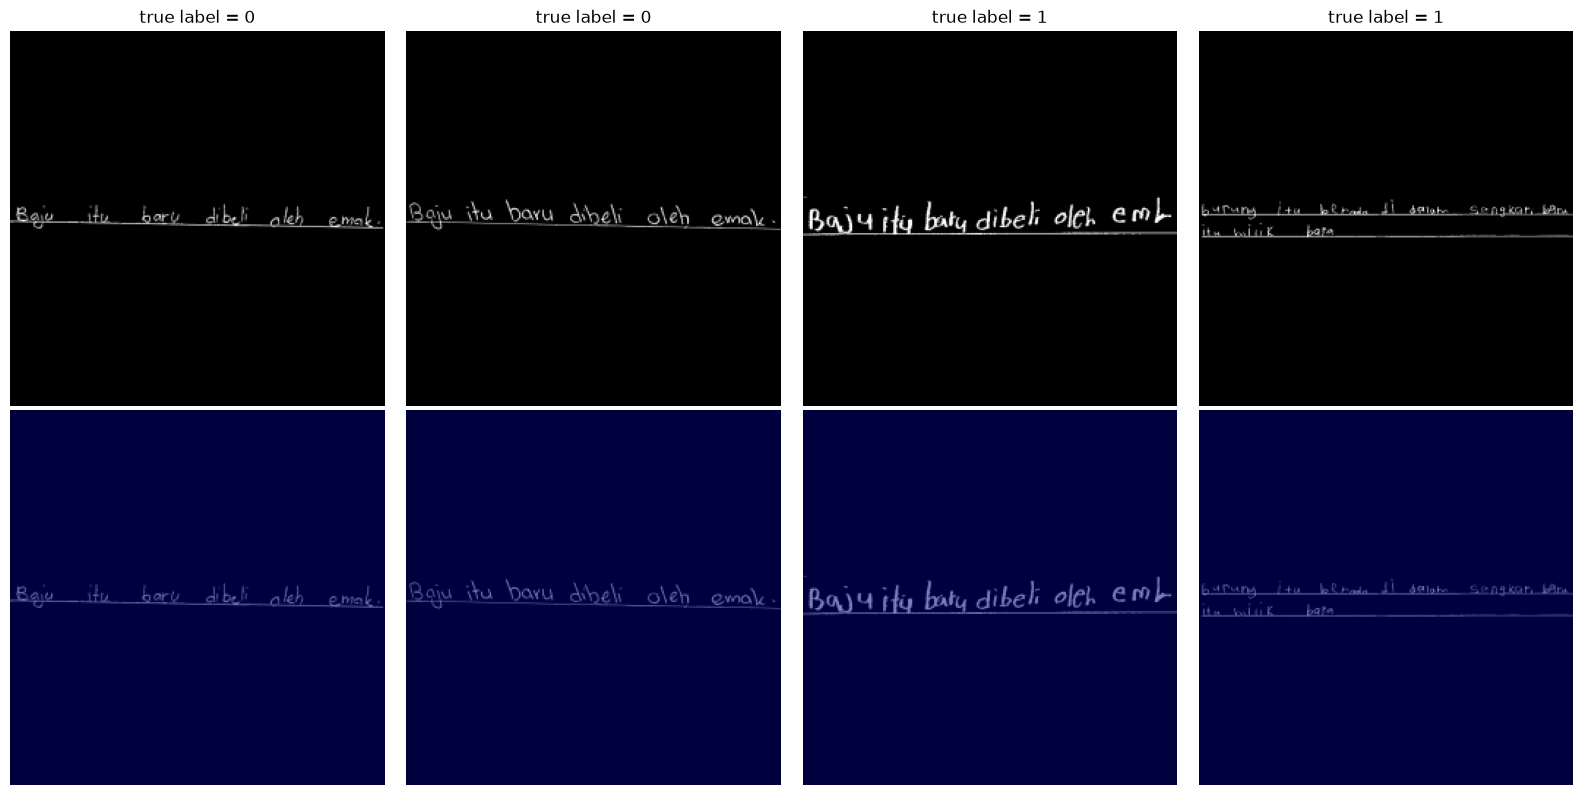

In [11]:
def gradcam_for(model, img):
    # dynamically find the last Conv2D layer so it works on any architecture
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None: return np.zeros((256, 256))

    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img[None, ...])
        score = predictions[0, 1] if predictions.shape[-1] == 2 else predictions[0, 0]

    grads = tape.gradient(score, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(weights[None, None, None, :] * conv_outputs, axis=-1)[0]
    cam = tf.nn.relu(cam)
    cam = (cam - tf.reduce_min(cam)) / (tf.reduce_max(cam) - tf.reduce_min(cam) + 1e-8)
    return tf.image.resize(cam[..., None], (256, 256))[..., 0].numpy()

# pick 2 Low + 2 Potential samples from the test set
idx = [i for i in range(len(y_test)) if y_test[i] == 0][:2] + \
      [i for i in range(len(y_test)) if y_test[i] == 1][:2]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, i in enumerate(idx):
    cam = gradcam_for(transfer, X_test[i])
    axes[0, j].imshow(X_test[i][..., 0], cmap="gray")
    axes[0, j].set_title(f"true label = {y_test[i]}")
    axes[0, j].axis("off")
    axes[1, j].imshow(X_test[i][..., 0], cmap="gray")
    axes[1, j].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()

## Verdict (honest, as the role asks)
- **Baseline CNN** collapses to the majority class on the test set: recall 0.00 for Potential, ROC AUC 0.366.
- **Transfer (MobileNetV2)**: test accuracy 0.50, ROC AUC 0.453 — below random.
- **Threshold sweep**: lowering the threshold to 0.30 only lifts recall to ~0.56 while precision stays ~0.47. A threshold cannot fix a model whose ranking is unreliable.
- **Grad-CAM**: heat is weak and diffuse along the line, not focused on specific strokes/baselines.

Conclusion: the current recipe is not deployment-ready. This is a recipe issue, not a data issue.

## Next A/B tests (same data, simpler recipe)
1. Aspect-ratio padding WITHOUT deskew/crop (the audit showed long strips; deskew may remove signal).
2. Fully frozen backbone first — unfreezing many layers on 149 training images overfits.
3. Evidence: a parallel independent experiment (Ahmed) with recipe 1+2 reached ROC AUC 0.838 on this same dataset. Run both pipelines side by side and let the test set decide.